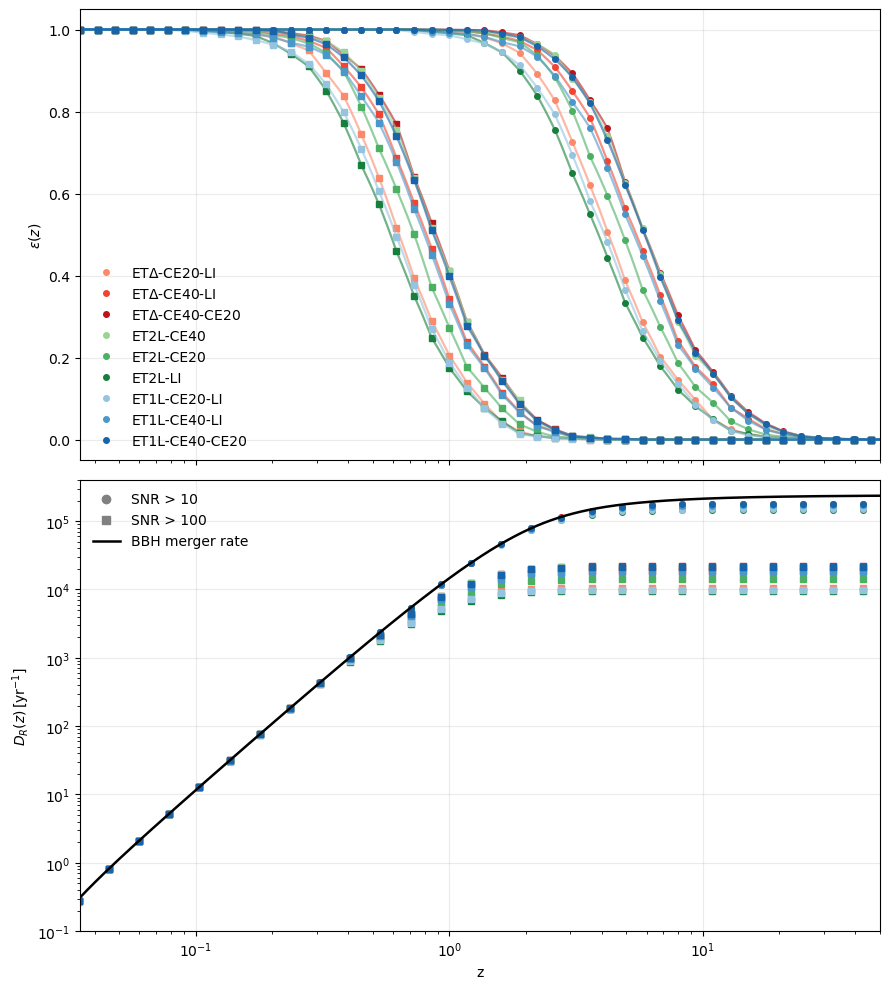

In [1]:
import h5py
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.lines import Line2D
from scipy.interpolate import interp1d


def load_curves(fname):
    with h5py.File(fname, "r") as f:
        zmid = f["efficiency/zmid"][()]
        eps10 = f["efficiency/efficiency10"][()]
        eps100 = f["efficiency/efficiency100"][()]
        z = f["rates/z"][()]
        det10 = f["rates/det_rate10"][()]
        det100 = f["rates/det_rate100"][()]
        merger = f["rates/merger_rate"][()]
    return zmid, eps10, eps100, z, det10, det100, merger


def plot_efficiency_and_rates(files, labels, colors):

    fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(9,10), sharex=True, gridspec_kw={"height_ratios": [1, 1]})

    merger_ref, z_ref = None, None
    z_xaxis = np.logspace(np.log10(0.035), np.log10(50.0), 600)

    for fname, label, color in zip(files, labels, colors):

        zmid, eps10, eps100, z, det10, det100, merger = load_curves(fname)

        ax1.plot(zmid, eps10, linestyle="none", marker="o", ms=4, color=color, label=label)
        ax1.plot(zmid, eps100, linestyle="none", marker="s", ms=4, color=color)

        eps10_z = interp1d(zmid, eps10, bounds_error=False, fill_value=0.0)
        eps100_z = interp1d(zmid, eps100, bounds_error=False, fill_value=0.0)

        ax1.plot(z_xaxis, eps10_z(z_xaxis), lw=1.6, alpha=0.6, color=color)
        ax1.plot(z_xaxis, eps100_z(z_xaxis), lw=1.6, alpha=0.6, color=color)

        ax2.plot(z, det10, linestyle="none", marker="o", markevery=70, ms=4, color=color)
        ax2.plot(z, det100, linestyle="none", marker="s", markevery=70, ms=4, color=color)

        if merger_ref is None:
            merger_ref, z_ref = merger, z

    ax2.plot(z_ref, merger_ref, lw=1.8, color="k")

    ax1.set_xscale("log")
    ax2.set_xscale("log")
    ax2.set_yscale("log")

    ax1.set_xlim(0.035, 50)
    ax2.set_xlim(0.035, 50)
    ax2.set_ylim(0.1, 4e5)
    
    ax1.set_ylabel(r"$\epsilon(z)$")
    ax2.set_ylabel(r"$D_R(z)\,[\mathrm{yr}^{-1}]$")
    ax2.set_xlabel("z")

    ax1.grid(alpha=0.25)
    ax2.grid(alpha=0.25)

    ax1.legend(loc="lower left", frameon=False)

    custom = [
        Line2D([0],[0], marker='o', color='gray', linestyle='none', label='SNR > 10'),
        Line2D([0],[0], marker='s', color='gray', linestyle='none', label='SNR > 100'),
        Line2D([0],[0], color='k', lw=1.8, label='BBH merger rate')
    ]

    ax2.legend(handles=custom, loc="upper left", frameon=False)
    plt.tight_layout()
    plt.savefig("efficiency-detection-rate.png", dpi=600)
    plt.show()


files = ["A BBH_ETD-CE20-LI_det.h5", "A BBH_ETD-CE40-LI_det.h5",  "A BBH_ETD-CE20-CE40_det.h5", 
         "B BBH_ET2L-CE40_det.h5", "B BBH_ET2L-CE20_det.h5", "B BBH_ET2L-LI_det.h5", 
         "C BBH_ET1L-CE20-LI_det.h5", "C BBH_ET1L-CE40-LI_det.h5", "C BBH_ET1L-CE40-CE20_det.h5" ]

labels = [r"ET$\Delta$-CE20-LI", r"ET$\Delta$-CE40-LI", r"ET$\Delta$-CE40-CE20",
          r"ET2L-CE40", r"ET2L-CE20", r"ET2L-LI",
          r"ET1L-CE20-LI", r"ET1L-CE40-LI", r"ET1L-CE40-CE20"]

reds   = plt.cm.Reds(np.linspace(0.4, 0.8, 3))
greens = plt.cm.Greens(np.linspace(0.4, 0.8, 3))
blues  = plt.cm.Blues(np.linspace(0.4, 0.8, 3))
colors = [reds[0], reds[1], reds[2], 
          greens[0], greens[1], greens[2],
          blues[0], blues[1], blues[2]]

#blues   = plt.cm.Blues(np.linspace(0.3, 0.8, 3))
#oranges = plt.cm.Oranges(np.linspace(0.35, 0.85, 3))
#greys   = plt.cm.Greys(np.linspace(0.4, 1, 3))
#colors = [blues[0], blues[1], blues[2], 
#          oranges[0], oranges[1], oranges[2],
#          greys[0], greys[1], greys[2]]

plot_efficiency_and_rates(files, labels, colors)

In [3]:
x = load_curves(files[0])

In [ ]:
print(x[6].max(), )
print(2*10**5)



235313.15502419716
200000


In [21]:
idx = np.where((x[3] >= 14.99) & (x[3] <= 15.1))
idx

(array([1692, 1693]),)

In [27]:
print(x[3][1692])
print(x[6][1692])

15.035756736485702
223139.9626703877
